# Project on Predicting Cotton Condition in Pakistan

In [ ]:
# Imports
import ee
import geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Authenticate and connect to GEE API
ee.Authenticate()  # opens browser once, caches token locally
ee.Initialize(project="cottoncondition")

In [ ]:
# Load file with field boundaries // Somehow first time this runs it fails??
fields = gpd.read_file(r"C:\Users\donle\Desktop\Cotton Condition\QGIS Project\Vector Layers\cotton_in_pakistan.shp")
fields = fields.to_crs(epsg=4326)  # GEE expects WGS84


In [5]:
# bounding box covering all fields, as an ee.Geometry
minx, miny, maxx, maxy = fields.total_bounds
aoi = ee.Geometry.Rectangle([minx, miny, maxx, maxy])

# fields themselves as an ee.FeatureCollection, for later per-field stats
fields_fc = geemap.geopandas_to_ee(fields)

In [17]:
start_date = "2022-04-01"
end_date   = "2022-10-31"

months = ee.List.sequence(4, 10)  

In [18]:
def mask_s2_clouds(image):
    scl = image.select("SCL")
    # keep vegetation, bare soil, water; drop cloud/shadow/cirrus/snow classes
    mask = scl.remap([4, 5, 6, 11], [1, 1, 1, 1], 0)
    return image.updateMask(mask).divide(10000).copyProperties(image, ["system:time_start"])

s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 40))
    .map(mask_s2_clouds)
)

In [19]:
s1 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(aoi)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.eq("orbitProperties_pass", "ASCENDING"))  # pick one orbit to avoid mixing angles
)

In [ ]:
def monthly_composite(collection, year):
    def _make(m):
        m = ee.Number(m)
        start = ee.Date.fromYMD(year, m, 1)
        end = start.advance(1, "month")
        img = collection.filterDate(start, end).median()
        return img.set("system:time_start", start.millis(), "month", m)
    return ee.ImageCollection(months.map(_make))

s2_monthly = monthly_composite(s2, 2022)
s1_monthly = monthly_composite(s1, 2022)

## Plot NDVI?

In [14]:
def add_ndvi(image):
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
    return image.addBands(ndvi)

s2_ndvi = s2.map(add_ndvi)
s2_ndvi_monthly = monthly_composite(s2_ndvi.select("NDVI"), 2022)

In [15]:
# pick a field by row index (or filter fields_fc by an ID column you have)
field_id = 50
field_geom = geemap.geopandas_to_ee(fields.iloc[[field_id]]).geometry()

def extract_ndvi(image):
    stat = image.reduceRegion(
        reducer=ee.Reducer.median(),
        geometry=field_geom,
        scale=10,
        maxPixels=1e9,
    )
    return ee.Feature(None, {
        "month": image.get("month"),
        "ndvi": stat.get("NDVI"),
    })

ndvi_fc = ee.FeatureCollection(s2_ndvi_monthly.map(extract_ndvi))
ndvi_list = ndvi_fc.getInfo()["features"]


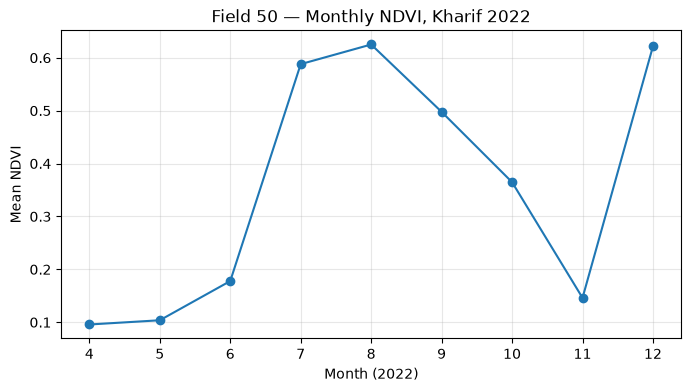

In [ ]:
records = [f["properties"] for f in ndvi_list]
df = pd.DataFrame(records).sort_values("month")

plt.figure(figsize=(8, 4))
plt.plot(df["month"], df["ndvi"], marker="o")
plt.xlabel("Month (2022)")
plt.ylabel("Mean NDVI")
plt.title(f"Field {field_id} — Monthly NDVI, Kharif 2022")
plt.grid(True, alpha=0.3)
plt.show()